# Emotion Classification with RNNs, LSTMs & GRUs
classifying text into 6 emotions (sadness, joy, love, anger, fear, surprise) by comparing plain recurrent models before building an Advanced Bidirectional GRU

Importing Libraries

In [37]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Library to import dataset form Hugging Face

from datasets import load_dataset

# Load Dataset

In [38]:
emotion_dataset = load_dataset('dair-ai/emotion')
emotion_dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [39]:
from datasets.packaged_modules import text
train_text      = emotion_dataset['train']['text']
train_label     = emotion_dataset['train']['label']

test_text       = emotion_dataset['test']['text']
test_label      = emotion_dataset['test']['label']

In [40]:
label_names = emotion_dataset['train'].features['label'].names

In [41]:
label_names

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

In [42]:
df_train = pd.DataFrame(
    {
        'text'  : train_text,
        'label' : [label_names[i] for i in train_label]
    }
)

df_test = pd.DataFrame(
    {
        'text'  : test_text,
        'label' : [label_names[i] for i in test_label]
    }
)

In [43]:
df_train.head()

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [44]:
df_test.head()

,text,label
0,im feeling rather rotten so im not very ambiti...,sadness
1,im updating my blog because i feel shitty,sadness
2,i never make her separate from me because i do...,sadness
3,i left with my bouquet of red and yellow tulip...,joy
4,i was feeling a little vain when i did this one,sadness


In [45]:
df_train.isnull().sum()

,0
text,0
label,0


# EDA

In [46]:
df_train['label'].value_counts()

,count
label,
joy,5362
sadness,4666
anger,2159
fear,1937
love,1304
surprise,572


<Axes: xlabel='label', ylabel='count'>

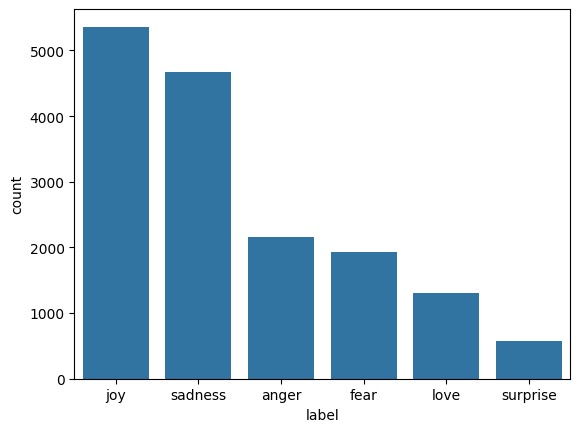

In [47]:
sns.countplot(x='label', data = df_train, order= df_train['label'].value_counts().index)

# Data Preprocessing Using NLP

In [48]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_words = 10000

tokenizer = Tokenizer(num_words = max_words, oov_token = '<UNK>')
tokenizer.fit_on_texts(df_train['text'])

train_sequence = tokenizer.texts_to_sequences(df_train['text'])
test_sequence = tokenizer.texts_to_sequences(df_test['text'])

In [49]:
padded_train_sequence = pad_sequences(train_sequence, maxlen=50, padding='post', truncating='post')
padded_test_sequence = pad_sequences(test_sequence, maxlen=50, padding='post', truncating='post')

padded_train_sequence

array([[   2,  139,    3, ...,    0,    0,    0],
       [   2,   40,  101, ...,    0,    0,    0],
       [  17, 3060,    7, ...,    0,    0,    0],
       ...,
       [   2,    3,  327, ...,    0,    0,    0],
       [   2,    3,   14, ...,    0,    0,    0],
       [   2,   47,    7, ...,    0,    0,    0]], dtype=int32)

In [50]:
train_labels = np.array(train_label)
test_labes = np.array(test_label)

In [51]:
num_classes = len(np.unique(train_labels))
num_classes

print(f"Vocab Size : {len(tokenizer.word_index)}")
print(f"Max Sentence lenght : {padded_train_sequence.shape[1]}")

Vocab Size : 15213
Max Sentence lenght : 50


# Shared Training Utility

In [52]:
# for computing the balanced class weights to handel dataset skew and setup early stoping

from sklearn.utils import class_weight

class_weight = class_weight.compute_class_weight(
    class_weight = 'balanced',
    classes = np.unique(train_labels),
    y = train_labels
)

class_weight_dict = dict(enumerate(class_weight))

In [53]:
from tensorflow.keras.callbacks import EarlyStopping

early_stoping = EarlyStopping(
    monitor = 'val_loss',
    patience = 3,
    restore_best_weights = True
)

# Making the Model (RNNs, LSTMs, GRUs)

**Simple RNN**

In [54]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout,LSTM, GRU

rnn_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128, input_length = 50),
    SimpleRNN(units=128, return_sequences=True),
    Dropout(0.5),
    SimpleRNN(units=64),
    Dropout(0.5),
    Dense(units = num_classes, activation = 'softmax')  # output layer
])

rnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',metrics=['accuracy'])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [55]:
rnn_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data = (padded_test_sequence, test_labes),
    epochs = 20,
    batch_size = 32,
    class_weight = class_weight_dict,
    callbacks = [early_stoping]
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - accuracy: 0.1593 - loss: 1.9027 - val_accuracy: 0.2105 - val_loss: 1.7819
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.1587 - loss: 1.8030 - val_accuracy: 0.1120 - val_loss: 1.8018
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.1616 - loss: 1.7857 - val_accuracy: 0.1015 - val_loss: 1.7978
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.1557 - loss: 1.7741 - val_accuracy: 0.0895 - val_loss: 1.7959


In [56]:
print(f"Simple RNN Test Loss : {rnn_model.evaluate(padded_test_sequence, test_labes)[0]}")
print(f"Simple RNN Test Accuracy : {rnn_model.evaluate(padded_test_sequence, test_labes)[1]}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2105 - loss: 1.7819
Simple RNN Test Loss : 1.781926155090332
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2105 - loss: 1.7819
Simple RNN Test Accuracy : 0.21050000190734863


**Standard LSTM**

In [57]:
Lstm_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128, input_length = 50),
    LSTM(units=128, return_sequences=True),
    Dropout(0.5),
    LSTM(units=64),
    Dropout(0.5),
    Dense(units = num_classes, activation = 'softmax')  # output layer
])

Lstm_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [ ]:
Lstm_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data = (padded_test_sequence, test_labes),
    epochs = 20,
    batch_size = 32,
    class_weight = class_weight_dict,
    callbacks = [early_stoping]
)

print(f"Simple LSTM Test Loss : {Lstm_model.evaluate(padded_test_sequence, test_labes)[0]}")
print(f"Simple LSTM Test Accuracy : {Lstm_model.evaluate(padded_test_sequence, test_labes)[1]}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.1573 - loss: 1.7953 - val_accuracy: 0.0355 - val_loss: 1.7921
Epoch 2/20
359/500 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.1353 - loss: 1.8010

**Standard GRU **

In [ ]:
gru_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128, input_length = 50),
    GRU(units=128, return_sequences=True),
    Dropout(0.5),
    GRU(units=64),
    Dropout(0.5),
    Dense(units = num_classes, activation = 'softmax')  # output layer
])

gru_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [ ]:
gru_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data = (padded_test_sequence, test_labes),
    epochs = 20,
    batch_size = 32,
    class_weight = class_weight_dict,
    callbacks = [early_stoping]
)

print(f"Simple GRU Test Loss : {gru_model.evaluate(padded_test_sequence, test_labes)[0]}")
print(f"Simple GRU Test Accuracy : {gru_model.evaluate(padded_test_sequence, test_labes)[1]}")

In [ ]:
result_df = pd.DataFrame({
    'Model' : ['RNN', 'LSTM', 'GRU'],
    'Test Loss' : [rnn_model.evaluate(padded_test_sequence, test_labes)[0], Lstm_model.evaluate(padded_test_sequence, test_labes)[0], gru_model.evaluate(padded_test_sequence, test_labes)[0]],
    'Test Accuracy' : [rnn_model.evaluate(padded_test_sequence, test_labes)[1], Lstm_model.evaluate(padded_test_sequence, test_labes)[1], gru_model.evaluate(padded_test_sequence, test_labes)[1]]
}).sort_values(by='Test Accuracy', ascending=False)

result_df


# Advance Bidirectional GRU

In [ ]:
# Enhance GRU with Bidirectional layers , 300D embedding and 0.5 dropout regularization

from tensorflow.keras.layers import Bidirectional

BiGru = Sequential([
    Embedding(input_dim = max_words, output_dim = 300, input_length = 50),
    Bidirectional(GRU(128, return_sequences=True)),
    Dropout(0.5),
    Bidirectional(GRU(64)),
    Dropout(0.5),
    Dense(num_classes, activation = 'softmax') # output layer
])

BiGru.compile(optimizer='adam', loss='sparse_categorical_crossentropy',metrics=['accuracy'])

BiGru.summary()

**Train and Evaluate**

In [ ]:
BiGru.fit(
    padded_train_sequence,
    train_labels,
    validation_data = (padded_test_sequence, test_labes),
    epochs = 20,
    batch_size = 32,
    class_weight = class_weight_dict,
    callbacks = [early_stoping]
)

In [ ]:
BiGru_loss, BiGru_accuracy = BiGru.evaluate(padded_test_sequence, test_labes)
print(f"BiGru Test Loss : {BiGru_loss}")
print(f"BiGru Test Accuracy : {BiGru_accuracy}")

# Additional Bidirectional LSTM

In [ ]:
from tensorflow.keras.layers import Bidirectional

BiLSTM = Sequential([
    Embedding(input_dim = max_words, output_dim = 300, input_length = 50),
    Bidirectional(LSTM(128, return_sequences=True)),
    Dropout(0.5),
    Bidirectional(LSTM(units=64)),
    Dropout(0.5),
    Dense(units = num_classes, activation = 'softmax')  # output layer
])

BiLSTM.compile(optimizer='adam', loss='sparse_categorical_crossentropy',metrics=['accuracy'])

BiLSTM.summary()

In [ ]:
BiLSTM.fit(
    padded_train_sequence,
    train_labels,
    validation_data = (padded_test_sequence, test_labes),
    epochs = 20,
    batch_size = 32,
    class_weight = class_weight_dict,
    callbacks = [early_stoping]
)

In [ ]:
BiLSTM_loss, BiLSTM_accuracy = BiLSTM.evaluate(padded_test_sequence, test_labes)
print(f"BiLSTM Test Loss : {BiLSTM_loss}")
print(f"BiLSTM Test Accuracy : {BiLSTM_accuracy}")

# Evaluation ans Bias Analysis

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

BiGru_predictions = np.argmax(BiGru.predict(padded_test_sequence),axis=1)

sns.heatmap(confusion_matrix(test_label, BiGru_predictions), annot = True, fmt = 'd', cmap= 'Blues', xticklabels = label_names, yticklabels = label_names)

# Final Prediction

In [ ]:
sample_text = [
    "I really enjoyed the movie because the story was interesting and the characters were well developed.",
    "I did not enjoy the experience because the service was slow and the staff was not helpful.",
    "I am feeling tired today because I had a busy schedule and worked on several assignments.",
    "I was shocked to see them loss the race",
    "I am feeling so bad for her",
    "I think this application is useful because it saves time and makes everyday tasks much easier."
]

sample_sequence = tokenizer.texts_to_sequences(sample_text)
sample_sequence = pad_sequences(sample_sequence, maxlen=50, padding='post', truncating='post')

sample_predictions = np.argmax(BiGru.predict(sample_sequence),axis=1)

for i in range(len(sample_text)):
    print(f"Text : {sample_text[i]}")
    print(f"Prediction : {label_names[sample_predictions[i]]}\n")

# Save and Tokenize the model

In [36]:
import os
import pickle

model_dir = 'Artifacts'
os.makedirs(model_dir, exist_ok= True)

# Saving our BiGRU Model
BiGru.save(os.path.join(model_dir, 'BiGru_model.keras'))

# Save the Tokenizer Model

with open(os.path.join(model_dir, 'tokenizer.pkl'),'wb') as file:
    pickle.dump(tokenizer, file)